<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Análise e projeto de vigas sujeitas à flexão. Diagramas de esforços internos.

### Problema 1

Sabendo que o varão ABC de secção circular com 20 mm de diâmetro está em equilíbrio sob a ação do carregamento indicado, desenhe os diagramas do esforço transverso e do momento fletor e determine a tensão normal máxima devida à flexão. Dados: $Q_0 = 750$ N/m, $L = 0.4$ m.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au04/P1/MSII_Au04_P1.png"
style="max-height: 100%; max-width: 100%;"/>

#### Dados do problema

In [49]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = "2"
if cor == "1":
    plt.rcParams["axes.facecolor"] = (0.15, 0.15, 0.15)
    plt.rcParams["figure.facecolor"] = (0.15, 0.15, 0.15)
    plt.rcParams["font.family"] = "monospace"
    plt.rcParams["font.size"] = 18
    # plt.rcParams['text.usetex'] = True
    params = {
        "ytick.color": (0.8, 0.8, 0.8),
        "xtick.color": (0.8, 0.8, 0.8),
        "grid.color": (0.2, 0.2, 0.2),
        "text.color": (0.7, 0.7, 0.7),
        "axes.labelcolor": (0.8, 0.8, 0.8),
        "axes.edgecolor": (0.15, 0.15, 0.15),
    }
else:
    plt.rcParams["axes.facecolor"] = (0.7, 0.7, 0.7)
    plt.rcParams["figure.facecolor"] = (0.7, 0.7, 0.7)
    plt.rcParams["font.family"] = "monospace"
    plt.rcParams["font.size"] = 18
    # plt.rcParams['text.usetex'] = True
    params = {
        "ytick.color": (0.1, 0.1, 0.1),
        "xtick.color": (0.1, 0.1, 0.1),
        "grid.color": (0.2, 0.2, 0.2),
        "text.color": (0.1, 0.1, 0.1),
        "axes.labelcolor": (0.1, 0.1, 0.1),
        "axes.edgecolor": (0.15, 0.15, 0.15),
    }
plt.rcParams.update(params)


# data structure, units: N, m, Pa
# Create an empty class
class varin:
    pass


dados = varin()
dados.Q = 750.0  # N/m
dados.L = 0.4  # m
dados.d = 20.0 * 1e-3  # m

## Resolução

### Análise do equilíbrio estático

- Carga distribuída no troço AB (à esquerda do apoio):

\begin{equation*}
w(x) = Q_0 - \frac{Q_0}{L}x = Q_0 \left(1 - \frac{x}{L}\right) \quad\textrm{[N]}
\quad\wedge\quad
x \in [0, L]
\end{equation*}

- Força resultante:

\begin{equation*}
F = \int_0^L w(x)\mathrm{d}x
= \int_0^L Q_0 \left(1 - \frac{x}{L}\right)\,\mathrm{d}x
= Q_0\left[x - \frac{x^2}{2L}\right]_0^L
= \frac{Q_0L}{2} \quad\textrm{[N]}
\end{equation*}

In [51]:
from scipy import integrate

# scipy.integrate is a module that contains functions for integration.
# Integration can be performed on a function defined by a lambda
# Integration can also be performed given an array of y values

w = lambda x: dados.Q * (1 - x / dados.L)
Resultante = integrate.quad(w, 0, dados.L)
F = Resultante[0]
print(f" F = {F:.1f} [N]")

 F = 150.0 [N]


- Centroide da linha de ação da carga resultante:

\begin{equation*}
\overline{x}
= \displaystyle\frac{\displaystyle\int_{0}^{L}w(x)x~\mathrm{d}x
}{\displaystyle\int_{0}^{L} w(x)\mathrm{d}x}
= \displaystyle\frac{\displaystyle\int_{0}^{L}Q_0 \left(1 - \frac{x}{L}\right)x~\mathrm{d}x
}{Q_0L/2}
= \frac{L}{3}\quad\textrm{[m]}
\end{equation*}

In [52]:
wx = lambda x: dados.Q * (1 - x / dados.L) * x
i1 = integrate.quad(wx, 0, dados.L)
xcent = i1[0] / F
print(f"integral = {i1[0]:.1f} | xcent = {xcent:.3f} m | {xcent*1e3:3.1f} mm²")

integral = 20.0 | xcent = 0.133 m | 133.3 mm²


- Equilíbrio estático: expressão dos momentos conduz a,

\begin{equation*}
\sum M_B^{\textrm{ext}} = 0
\quad\therefore\quad
M_B^{\textrm{ext}} = 2 \left[ \frac{Q_0L}{2}
\left(\frac{2L}{3}\right) \right]
\quad\textrm{[N.m]}
\end{equation*}

In [53]:
MB_ext = 2 * (dados.Q * dados.L / 2) * (2 * dados.L / 3)
print(f"Mc = {MB_ext:3.1f} N.m")

Mc = 80.0 N.m


- Equilíbrio estático: expressão escalar do sumatório das forças segundo o eixo $y$ (cálculo da reação em C):

\begin{equation*}
\sum F_y = 0
\quad\Leftrightarrow\quad R_{yc} = 0
\quad\textrm{[N]}
\end{equation*}

### Diagrama de Esforços: Método das secções

#### Troço AB : **$~0<x<L$**

Os diagramas de esforços - esforço tranverso, $V(x)$ e momento fletor, $M(x)$ - podem ser determinados recorrendo ao método das secções:

##### Método de cálculo 1
 
Este método aplica diretamente as equações de equilíbrio estático à secção AB em análise, considerando o carregamento trapezoidal. Por essa razão, é mais adequado para implementação em programação do que para o cálculo analítico.
 
\begin{equation*}
\begin{cases}
\sum F_y = 0 \\
\sum M_{B'} = 0 \\
\end{cases}~\Leftrightarrow~
\begin{cases}
- \displaystyle\int_0^xw(\overline{x})\mathrm{d}\overline{x} - V(x) = 0 \quad\wedge\quad w(x) = Q_0 \left(1 - \frac{x}{L}\right) \\
\displaystyle\int_0^xw(\overline{x})\mathrm{d}\overline{x}\cdot \left(x-
- \underbrace{\frac{\displaystyle\int_0^xw(\overline{x})\overline{x}\mathrm{d}\overline{x}}
{\displaystyle\int_0^xw(\overline{x})\mathrm{d}\overline{x}}}_{\overline{x}} \right) +M(x)= 0 \\
\end{cases}
\end{equation*}

In [65]:
vab, mab, x = sy.symbols("vab mab x")
# integral calculations
f1 = dados.Q * (1 - x / dados.L)
ii1 = sy.integrate(f1, (x, 0, x))
print("ii1 = int f(x) : ", ii1)
f2 = f1 * x  # integrant function
ii2 = sy.integrate(f2, (x, 0, x))
print("ii2 = int f(x).x ", ii2)

sumFy = -ii1 - vab
print(f"\nSystem of Equations:\n--------------------\nsumFy = 0 : {sumFy} = 0 [N]")
sumMA = ii1 * (x - ii2 / ii1) + mab
print(f"sumMA = {sumMA} ")
print(f"      = {sy.factor(sumMA)} = 0 [N.m]")

sol = solve({sumFy, sumMA}, {vab, mab})

print("---------")
print("Troço AB:")
print("---------")
VAB = sol[vab]
print(f"Esforço Transverso, V(x) = {VAB} [N]")
MAB = sol[mab]
print(f"Momento fletor, M(x) = {MAB} [N.m]")

print("\n --- Valores nos extremos do intervalo: --")
VAB_A = VAB.subs({(x, 0)})
MAB_A = MAB.subs({(x, 0)})
VAB_B = VAB.subs({(x, dados.L)})
MAB_B = MAB.subs({(x, dados.L)})

print(f"VAB(x=0)   = {VAB_A:.1f} N")
print(f"MAB(x=0)   = {MAB_A:.1f} N.m")
print(f"VAB(x=LAB) = {VAB_B:.1f} N")
print(f"MAB(x=LAB) = {MAB_B:.1f} N.m")

ii1 = int f(x) :  -937.5*x**2 + 750.0*x
ii2 = int f(x).x  -625.0*x**3 + 375.0*x**2

System of Equations:
--------------------
sumFy = 0 : -vab + 937.5*x**2 - 750.0*x = 0 [N]
sumMA = mab + (x - (-625.0*x**3 + 375.0*x**2)/(-937.5*x**2 + 750.0*x))*(-937.5*x**2 + 750.0*x) 
      = -375.0*(-0.00266666666666667*mab + 0.833333333333333*x**3 - 1.0*x**2) = 0 [N.m]
---------
Troço AB:
---------
Esforço Transverso, V(x) = 937.5*x**2 - 750.0*x [N]
Momento fletor, M(x) = 312.5*x**3 - 375.0*x**2 [N.m]

 --- Valores nos extremos do intervalo: --
VAB(x=0)   = 0.0 N
MAB(x=0)   = 0.0 N.m
VAB(x=LAB) = -150.0 N
MAB(x=LAB) = -40.0 N.m


##### Método de cálculo 2

Uma vez que apenas existe um carregamento distribuido ao longo de troço AB, as expressões do esforço transverso e momenot fletor podem ser facilmente calculados por integração (ver formulário Apêncide).

A expressão do momento fletor pode ser mais facilmente determinada neste caso por,

\begin{equation*}
V_{AB}(x) = -\int_0^x w(\overline{x})\mathrm{d}\overline{x} \quad \wedge \quad V_A = 0
\end{equation*}

\begin{equation*}
M_{AB}(x) = \int_0^x V_{AB}(\overline{x})\mathrm{d}\overline{x} \quad \wedge \quad M_A = 0
\end{equation*}


In [67]:
VAB_2 = sy.integrate(-f1, (x, 0, x))
print(f"Esforço Transverso, V(x) = {VAB_2} [N.m]")

MAB_2 = sy.integrate(VAB_2, (x, 0, x))
print(f"Momento fletor, M(x) = {MAB_2} [N.m]")

Esforço Transverso, V(x) = 937.5*x**2 - 750.0*x [N.m]
Momento fletor, M(x) = 312.5*x**3 - 375.0*x**2 [N.m]


#### Troço BC : **$~L<x<2L$**

Os diagramas de esforços internos - esforço tranverso, $V(x)$ e momento fletor, $M(x)$ - podem ser determinados recorrendo ao método das secções escolhendo o referêncial global:

##### Método de cálculo 1 (referencial global)

\begin{equation*}
V(x) = V_B - \int_L^x w(\overline{x})\mathrm{d}\overline{x}
\quad\wedge\quad 
V_B = V_{AB}(x=L)
\quad\wedge\quad 
w(x) = Q_0 \left(1 - \frac{x}{L}\right) 
\quad\wedge\quad
x \in [L, 2L[
\end{equation*}

\begin{equation*}
M(x) = M_B + \int_L^x V(\overline{x})\mathrm{d}\overline{x}
\quad\wedge\quad
M_B = M_{AB}(x=L) + M_B^\textrm{ext}
\end{equation*}

In [70]:
vbc, mbc = sy.symbols("vbc mbc")

iii1 = sy.integrate(f1, (x, dados.L, x))
vbc = VAB_B - iii1

iii2 = sy.integrate(vbc, (x, dados.L, x))
mbc = MAB_B + MB_ext + iii2

print("---------")
print("Troço BC (Versao global):")
print("---------")
print(f"Esforço Transverso, V(x) = {vbc} [N]")
print(f"Momento fletor, M(x) = {mbc} [N.m]")

print("\n --- Valores nos extremos do intervalo: --")
VBC_B = vbc.subs({(x, dados.L)})
MBC_B = mbc.subs({(x, dados.L)})
VBC_C = vbc.subs({(x, 2 * dados.L)})
MBC_C = mbc.subs({(x, 2 * dados.L)})

print(f"VBC(x=L)  = {VBC_B:.1f} N")
print(f"MBC(x=L)  = {MBC_B:.1f} N.m")
print(f"VBC(x=2L) = {VBC_C:.2f} N")
print(f"MBC(x=2L) = {np.abs(MBC_C):.2f} N.m")

---------
Troço BC (Versao global):
---------
Esforço Transverso, V(x) = 937.5*x**2 - 750.0*x [N]
Momento fletor, M(x) = 312.5*x**3 - 375.0*x**2 + 80.0 [N.m]

 --- Valores nos extremos do intervalo: --
VBC(x=L)  = -150.0 N
MBC(x=L)  = 40.0 N.m
VBC(x=2L) = 0.00 N
MBC(x=2L) = 0.00 N.m


##### Método de cálculo 2 (referencial local)

Os diagramas de esforços internos - esforço tranverso, $V(x)$ e momento fletor, $M(x)$ - podem ser determinados também recorrendo ao método das secções aplicado a um referêncial local do tramo BC:

\begin{equation*}
V'(x) = V_B - \int_0^x w'(\overline{x})\mathrm{d}\overline{x}
\quad\wedge\quad
w'(x) = -\frac{Q_0}{L}x
\quad\wedge\quad
x \in [L, 2L]
\end{equation*}

\begin{equation*}
M(x) = M_B + \int_0^x V'(\overline{x})\mathrm{d}\overline{x}
\quad\wedge\quad
M_B = M_{AB}(x=L) + M_B
\end{equation*}

In [73]:
vbc_loc, mbc_loc = sy.symbols("vbc_loc mbc_loc")

f3 = -dados.Q / dados.L * x
vbc_loc = VAB_B - sy.integrate(f3, (x, 0, x))
mbc_loc = MAB_B + MB_ext + sy.integrate(vbc_loc, (x, 0, x))

print("---------")
print("Troço BC (versao local):")
print("---------")
print(f"Esforço Transverso, V(x) = {vbc_loc} [N]")
print(f"Momento fletor, M(x) = {mbc_loc} [N.m]")

print("\n --- Valores nos extremos do intervalo: --")
positions = [(0, "0"), (dados.L, "L")]

for pos, label in positions:
    VBC = vbc_loc.subs(x, pos)
    MBC = mbc_loc.subs(x, pos)
    
    print(f"VBC(x={label}) = {VBC:.2f} N")
    print(f"MBC(x={label}) = {abs(MBC):.2f} N.m")

---------
Troço BC (versao local):
---------
Esforço Transverso, V(x) = 937.5*x**2 - 150.0 [N]
Momento fletor, M(x) = 312.5*x**3 - 150.0*x + 40.0 [N.m]

 --- Valores nos extremos do intervalo: --
VBC(x=0) = -150.00 N
MBC(x=0) = 40.00 N.m
VBC(x=L) = 0.00 N
MBC(x=L) = 0.00 N.m


#### Diagrama de Esforço Transverso

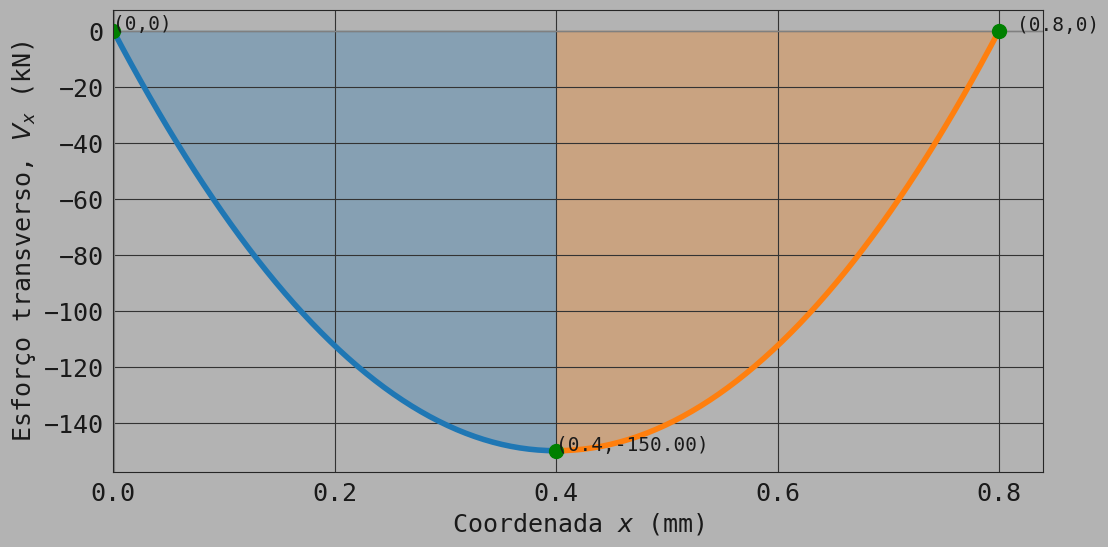

In [58]:
xAB = np.linspace(0, dados.L)
xBC = np.linspace(dados.L, 2 * dados.L)


def sy2array(sygunc, xlist):
    scalar_func = lambda xx: float(sygunc.evalf(subs={x: xx}))
    vector_func = np.vectorize(scalar_func)
    return vector_func(xlist)


# AB
yVAB, yMAB = sy2array(VAB, xAB), sy2array(MAB, xAB)
# BC
yVBC, yMBC = sy2array(vbc, xBC), sy2array(mbc, xBC)

fz = 14
fig, ax = plt.subplots(figsize=(12, 6))
plt.axhline(linewidth=1, color=(0.5, 0.5, 0.5))
plt.axvline(linewidth=3, color=(0.5, 0.5, 0.5))
plt.plot(xAB, yVAB, linewidth=4)
plt.fill_between(xAB, yVAB, alpha=0.3)
plt.plot(xBC, yVBC, linewidth=4)
plt.fill_between(xBC, yVBC, alpha=0.3)
plt.xlabel("Coordenada $x$ (mm)")
plt.ylabel("Esforço transverso, $V_{x}$ (kN)")
plt.plot(xAB[0], yVAB[0], "go", markersize=10)
plt.text(xAB[0], yVAB[0] + 0.3, f"({xAB[0]:.0f},{yVAB[0]:.0f})", fontsize=fz)
plt.plot(xAB[-1], yVAB[-1], "go", markersize=10)
plt.text(xAB[-1] * 1.0, yVAB[-1] * 1.0, f"({xAB[-1]:.1f},{yVAB[-1]:.2f})", fontsize=fz)
plt.plot(xBC[-1], yVBC[-1], "go", markersize=10)
plt.text(xBC[-1] * 1.02, yVBC[-1] * 1.0, f"({xBC[-1]:.1f},{yVBC[-1]:.0f})", fontsize=fz)
plt.xlim(0, 2 * dados.L * 1.05)
ax.xaxis.set_ticks_position("none")
ax.yaxis.set_ticks_position("none")
# Customize minor tick labels
xrang = np.round(np.arange(0, 2 * dados.L * 1.1, 0.2), 2)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
# plt.ylim(-int(P4.p2*2),int(P4.p2*2))
plt.grid(True)
plt.show()

#### Diagrama de Momento Fletor

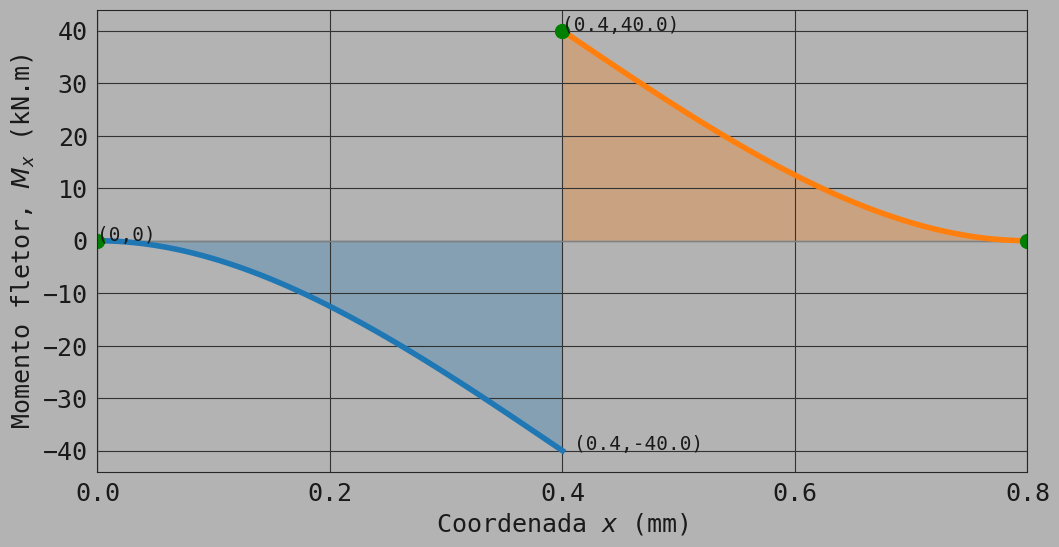

In [59]:
fig, ax = plt.subplots(figsize=(12, 6))
plt.axhline(linewidth=1, color=(0.5, 0.5, 0.5))
plt.axvline(linewidth=1, color=(0.5, 0.5, 0.5))
plt.plot(xAB, yMAB, linewidth=4)
plt.fill_between(xAB, yMAB, alpha=0.3)
plt.plot(xBC, yMBC, linewidth=4)
plt.fill_between(xBC, yMBC, alpha=0.3)
plt.xlabel(r"Coordenada $x$ (mm)")
plt.ylabel(r"Momento fletor, $M_{x}$ (kN.m)")
plt.plot(xAB[0], yMAB[0], "go", markersize=10)
plt.text(xAB[0] * 1.0, yMAB[0], f"({xAB[0]:.0f},{yMAB[0]:.0f})", fontsize=fz)
plt.text(xAB[-1] + 0.01, yMAB[-1] + 0.1, f"({xAB[-1]:.1f},{yMAB[-1]:.1f})", fontsize=fz)
plt.plot(xBC[0], yMBC[0], "go", markersize=10)
plt.text(xBC[0] * 1.0, yMBC[0] * 1.0, f"({xBC[0]:.1f},{yMBC[0]:.1f})", fontsize=fz)
plt.plot(xBC[-1], yMBC[-1], "go", markersize=10)
plt.xlim(0, dados.L * 1.05)
ax.xaxis.set_ticks_position("none")
ax.yaxis.set_ticks_position("none")
# Customize minor tick labels
xrang = np.round(np.arange(0, 2 * dados.L * 1.1, 0.2), 2)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
plt.grid(True)
plt.show()

- Tensão normal devido à flexão (Fórmula de Euler):


\begin{equation*}
|\sigma_{xx}| = \frac{M_z}{I_z} y
\quad\wedge\quad  
I_z^\bigcirc = \frac{\pi r⁴}{4}
\quad\wedge\quad  
|\sigma_{xx}^{max}| = \frac{4M_z}{\pi r³}
\end{equation*}


In [60]:
def izcirc(r):
    return np.pi * r**4 / 4


Iz = izcirc(dados.d / 2)
print(f"Iz = {Iz:3.6e} m⁴ | {Iz*1e12:3.6e} mm⁴")

Iz = 7.853982e-09 m⁴ | 7.853982e+03 mm⁴


In [61]:
Mmax = mbc.subs({(x, dados.L)})
print(f"M Max = {Mmax:.1f} N.m")
ymax = dados.d / 2
sigx = Mmax / Iz * ymax
print(f"sigx = {sigx*1e-6:.2f} MPa")

M Max = 40.0 N.m
sigx = 50.93 MPa


### Apêndice: Relações entre carga, esforço cortante e momento fletor

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au04/P1/FormDiagramas.png"
width="400"/>

- Esforço transverso:
  
\begin{equation*}
V_D − V_C = − \int_{x_C}^{x_D} w(x) \mathrm{d} x
\end{equation*}


ou seja, $V_D − V_C$ = −(área sob a curva de carga entre C e D)

- Momento fletos:
  
\begin{equation*}
M_D − M_C = \int_{x_C}^{x_D} V(x) \mathrm{d} x
\end{equation*}


ou seja, $M_D − M_C$ = área sob a curva de esforço cortante entre C e D

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>